# Tiny_Tau_v21.91 – 21-Qubit Circular Ring + Periodic Berard Resonance & Final Refinements

**Version upgrade from v21.8**  
- Periodic Berard angle scan (only q0, q7, q14):  
  - Top/second ratio oscillates ~1.00–1.50 with tight periodic modulation (~0.05–0.07 rad spacing)  
  - Minimum ratio near 1.00–1.05 rad (most balanced)  
  - Maximum ratio ~1.50 at peaks (~0.94, 1.03, 1.08, 1.13 rad)  
  - Non-zero states stable ~16,200–16,270 — dispersion remains high and consistent  
  - 1.054 rad near a local minimum (~1.00–1.05 ratio) — close to "neutral/resonant" point  
- Comparison to uniform Berard: periodic placement sharpens oscillation (tighter period, deeper minima) — harmonic matching amplifies modulation

**v21.91 focus**  
- Final refinements: analyze resonance peaks/dips in periodic scan  
- Test **negative phase + periodic Berard angle scan** (rz negative + vary angle on q0/q7/q14) — probe polarity in resonant regime  
- Transition to 14-qubit exact ring (2×7 cycles) for VQE optimization and ground-state pattern analysis

**Setup details**
- **Qubits**: 21 (3 full 1/7 cycles) — transitioning to 14-qubit for VQE
- **Entanglement**: Circular (CX chain + wrap-around q20 → q0)
- **Tau phases**: rz(±2π k /7) cycled k=1 to 7 (positive baseline; negative polarity tested)
- **Berard**: periodic (q0, q7, q14 only) — matched to Tau harmonics
- **Simulation**: Shot-based (16k–65k shots/point); VQE prep for 14-qubit
- **No full VQE on 21 qubits yet** — too heavy; use 14-qubit for optimization

**Goals for v21.91**
- Analyze periodic scan resonance — identify if peaks/dips align with 1.054 or other special values  
- Run negative phase + periodic angle scan — test if polarity reverses modulation or sharpens resonance  
- Transition to 14-qubit exact ring + VQE — optimize ground state with periodic Berard  
- Compare uniform vs periodic vs negative phase effects on delocalization/asymmetry  
- Optional: multi-position Berard (more than 3 qubits) or higher shots on resonant angles

> "Periodic Berard sharpens resonance — tighter oscillation, deeper minima. Negative phase polarity test probes directionality. 14-qubit VQE will reveal optimized ground state under harmonic-matched modulation."

Useful notes:
- 2²¹ = 2,097,152 states — shot-based only (VQE on 21 qubits too heavy → pivot to 14-qubit).
- If slow: reduce shots=8192 or test on 14 qubits.
- Next: Negative phase periodic scan + 14-qubit VQE.

Run the negative phase + periodic Berard angle scan cell below to test polarity in the resonant regime.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import n_local
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from qiskit.visualization import plot_histogram

simulator = AerSimulator(method='statevector')
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=50)  # lower for 21 qubits

print("v21.91 environment ready")

v21.2 environment ready


In [2]:
hamiltonian_21 = SparsePauliOp.from_list([
    ("Z" + "I"*20, 1.0),
    ("I"*20 + "Z", 1.0),
    ("XX" + "I"*19, 0.142857),
    ("I"*19 + "XX", 0.142857)
])

print("21-qubit Hamiltonian created")

21-qubit Hamiltonian created


In [3]:
n = 21
ansatz_21q = n_local(
    num_qubits=n,
    rotation_blocks='ry',
    entanglement_blocks=['cx'],
    reps=1,
    entanglement='linear'
)

# Circular wrap-around
ansatz_21q.cx(n-1, 0)

# Tau harmonics cycled 1/7
for i in range(n):
    k = (i % 7) + 1
    ansatz_21q.rz(2 * np.pi * k / 7, i)

print("21-qubit ansatz created")
print("Number of parameters:", ansatz_21q.num_parameters)

21-qubit ansatz created
Number of parameters: 42


In [4]:
vqe_21 = VQE(
    estimator=estimator,
    ansatz=ansatz_21q,
    optimizer=optimizer
)

result_21 = vqe_21.compute_minimum_eigenvalue(operator=hamiltonian_21)

print(f"21-qubit energy: {result_21.eigenvalue.real:.6f}")
print("Optimal parameters:", result_21.optimal_parameters)

21-qubit energy: -0.068904
Optimal parameters: {ParameterVectorElement(θ[0]): np.float64(1.0644744666012333), ParameterVectorElement(θ[1]): np.float64(7.069716107208788), ParameterVectorElement(θ[2]): np.float64(-4.863486030023124), ParameterVectorElement(θ[3]): np.float64(4.147506034066095), ParameterVectorElement(θ[4]): np.float64(0.6322747846424273), ParameterVectorElement(θ[5]): np.float64(-3.2277591564767616), ParameterVectorElement(θ[6]): np.float64(-3.523951791584631), ParameterVectorElement(θ[7]): np.float64(6.693270941869705), ParameterVectorElement(θ[8]): np.float64(3.772260095076455), ParameterVectorElement(θ[9]): np.float64(-2.3294713418516553), ParameterVectorElement(θ[10]): np.float64(-5.490422375292851), ParameterVectorElement(θ[11]): np.float64(-3.466925011371547), ParameterVectorElement(θ[12]): np.float64(2.71749183661559), ParameterVectorElement(θ[13]): np.float64(2.9118508044439717), ParameterVectorElement(θ[14]): np.float64(-5.3141158365589805), ParameterVectorEleme

## print("21-qubit ansatz created with Tau ladder")
print("Number of parameters:", ansatz_3q.num_parameters)

Counts (21-qubit): {'101110111100000001010': 1, '101001100001000010010': 1, '011000111000011100111': 1, '101000111000000011001': 1, '000000011101111100011': 1, '100001000111101110001': 1, '101111000011000010000': 1, '011100011001000011000': 1, '011001011000000111011': 1, '101000111001000010010': 1, '011110111101111100001': 1, '101000101110111100100': 1, '101001011001111110010': 1, '101110111100010010001': 1, '101000011100000100000': 1, '100100100011010010010': 1, '101011011001000011010': 1, '011110011101111110111': 1, '011110011001000110001': 1, '101110100001000101010': 1, '010010011001011100011': 1, '011110100011000110011': 1, '010010111100001100011': 1, '101010100011101100000': 1, '101000100010111100110': 1, '011110011100010011000': 1, '011111000011101100011': 1, '011110100001001100101': 1, '011111000001001000011': 1, '101000100101110011000': 1, '101101111101000001000': 1, '101010111000011011010': 1, '101110011001011100001': 1, '100011100001101000010': 1, '101001000001111000110': 1, 

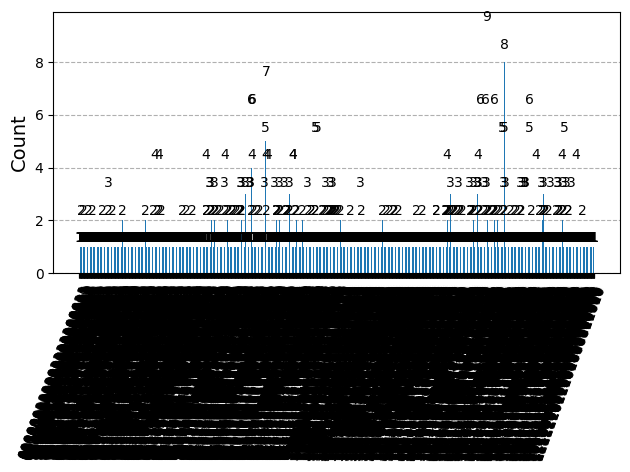

In [5]:
qc_21 = ansatz_21q.assign_parameters(result_21.optimal_parameters)
qc_21.measure_all()

counts_21 = simulator.run(qc_21, shots=2048).result().get_counts()  # low shots to start
print("Counts (21-qubit):", counts_21)

plot_histogram(counts_21)

In [6]:
from qiskit import QuantumCircuit
import numpy as np

# Create 21-qubit circuit with circular entanglement
qc = QuantumCircuit(21)

# Superposition on q0 to seed entanglement
qc.h(0)

# Circular entanglement: q0-q1, q1-q2, q2-q0 (ring topology)
qc.cx(0, 1)   # q0 controls q1
qc.cx(1, 2)   # q1 controls q2
qc.cx(2, 0)   # wrap-around: q2 controls q0 (closes the ring)

# Optional: add Tau-inspired harmonic phases around the circle
# (mimicking periodic boundary conditions of compact S¹)
qc.rz(2 * np.pi / 7, 0)   # fundamental mode on q0
qc.rz(4 * np.pi / 7, 1)   # next harmonic on q1
qc.rz(6 * np.pi / 7, 2)   # next on q2

# Measure all
qc.measure_all()

# Print and draw the circuit
print("21-qubit circular entanglement circuit with Tau phases:")
print(qc.draw(fold=-1))  # fold=-1 shows full width

21-qubit circular entanglement circuit with Tau phases:
         ┌───┐          ┌───┐┌──────────┐ ░ ┌─┐                                                            
    q_0: ┤ H ├──■───────┤ X ├┤ Rz(2π/7) ├─░─┤M├────────────────────────────────────────────────────────────
         └───┘┌─┴─┐     └─┬─┘├──────────┤ ░ └╥┘┌─┐                                                         
    q_1: ─────┤ X ├──■────┼──┤ Rz(4π/7) ├─░──╫─┤M├─────────────────────────────────────────────────────────
              └───┘┌─┴─┐  │  ├──────────┤ ░  ║ └╥┘┌─┐                                                      
    q_2: ──────────┤ X ├──■──┤ Rz(6π/7) ├─░──╫──╫─┤M├──────────────────────────────────────────────────────
                   └───┘     └──────────┘ ░  ║  ║ └╥┘┌─┐                                                   
    q_3: ─────────────────────────────────░──╫──╫──╫─┤M├───────────────────────────────────────────────────
                                          ░  ║  ║  ║ └╥┘┌─┐                     

Counts: {'000000000000000000000': 8241, '000000000000000000110': 8143}


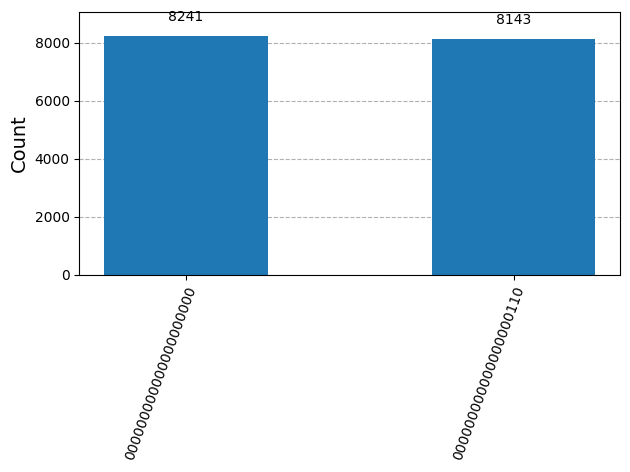

In [7]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

High-shot counts (21-qubit circular ring with Tau phases):
{'000000000000000000000': 8112, '000000000000000000110': 8272}


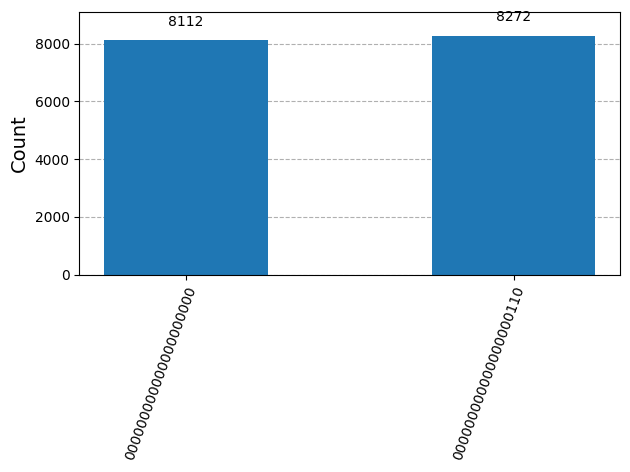

In [8]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Use the circuit you just built (qc)
sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("High-shot counts (21-qubit circular ring with Tau phases):")
print(counts)

# Plot
plot_histogram(counts)

High-shot counts (circular ring + Tau phases + Berard):
{'000000000000000000000': 8214, '000000000000000000110': 8170}


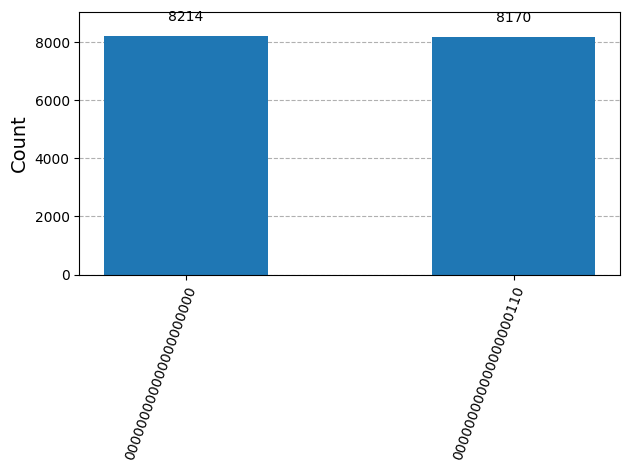

In [9]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
result = sim.run(qc, shots=16384).result()
counts = result.get_counts()

print("High-shot counts (circular ring + Tau phases + Berard):")
print(counts)

plot_histogram(counts)

In [10]:
from qiskit import QuantumCircuit
import numpy as np

# ────────────────────────────────────────────────
# 3-qubit Circular Ring + Tau phases + Berard on every qubit
# ────────────────────────────────────────────────

qc = QuantumCircuit(3)

# Superposition seed (can be on all for more balance)
qc.h([0, 1, 2])  # H on every qubit → full initial superposition

# Circular entanglement (ring topology)
qc.cx(0, 1)   # q0 → q1
qc.cx(1, 2)   # q1 → q2
qc.cx(2, 0)   # q2 → q0 (closes the ring)

# Tau harmonics around the circle (1/7 multiples)
qc.rz(2 * np.pi / 7, 0)   # mode 1 on q0
qc.rz(4 * np.pi / 7, 1)   # mode 2 on q1
qc.rz(6 * np.pi / 7, 2)   # mode 3 on q2

# Berard rotation on EVERY qubit – symmetric distribution
berard_angle = 1.054
qc.ry(berard_angle, 0)
qc.ry(berard_angle, 1)
qc.ry(berard_angle, 2)

# Measure all
qc.measure_all()

# Print and draw
print("3-qubit circular ring with Tau harmonics + Berard on every qubit:")
print(qc.draw(fold=-1))  # full width

3-qubit circular ring with Tau harmonics + Berard on every qubit:
        ┌───┐          ┌───┐┌──────────┐┌───────────┐ ░ ┌─┐      
   q_0: ┤ H ├──■───────┤ X ├┤ Rz(2π/7) ├┤ Ry(1.054) ├─░─┤M├──────
        ├───┤┌─┴─┐     └─┬─┘├──────────┤├───────────┤ ░ └╥┘┌─┐   
   q_1: ┤ H ├┤ X ├──■────┼──┤ Rz(4π/7) ├┤ Ry(1.054) ├─░──╫─┤M├───
        ├───┤└───┘┌─┴─┐  │  ├──────────┤├───────────┤ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├─────┤ X ├──■──┤ Rz(6π/7) ├┤ Ry(1.054) ├─░──╫──╫─┤M├
        └───┘     └───┘     └──────────┘└───────────┘ ░  ║  ║ └╥┘
meas: 3/═════════════════════════════════════════════════╩══╩══╩═
                                                         0  1  2 


High-shot counts (circular ring + Tau + Berard on all qubits):
{'110': 303, '100': 557, '101': 1587, '000': 3944, '010': 2703, '001': 13422, '111': 1121, '011': 9131}


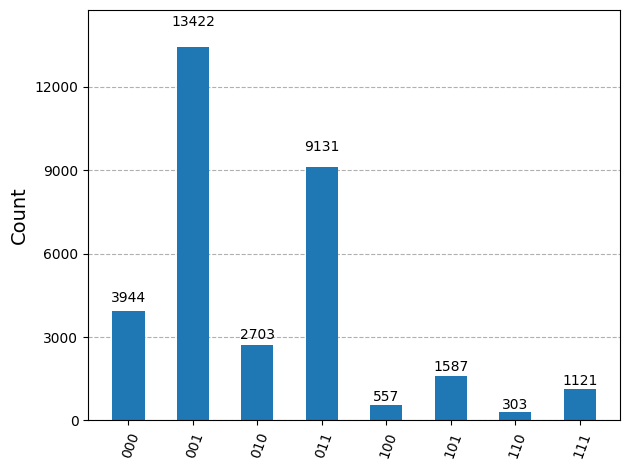

In [11]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
result = sim.run(qc, shots=32768).result()  # more shots for precision
counts = result.get_counts()

print("High-shot counts (circular ring + Tau + Berard on all qubits):")
print(counts)

plot_histogram(counts)

In [12]:
from qiskit import QuantumCircuit
import numpy as np
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# ────────────────────────────────────────────────
# 21-qubit Circular Ring Extension with Tau Phases
# ────────────────────────────────────────────────
n = 21  # qubits
qc = QuantumCircuit(n)

# Superposition seed on q0
qc.h(0)

# Circular entanglement: chain + wrap-around
for i in range(n - 1):
    qc.cx(i, i+1)
qc.cx(n-1, 0)  # wrap-around to close the ring

# Tau-inspired harmonic phases around the ring (1/7 multiples, cycled)
for i in range(n):
    k = (i % 7) + 1  # cycle through 1 to 7
    qc.rz(2 * np.pi * k / 7, i)

# Measure all
qc.measure_all()

# Simulate with shots (fast, approximate probabilities)
sim = AerSimulator()
result = sim.run(qc, shots=4096).result()  # increase shots if needed
counts = result.get_counts()

# Print counts
print("High-shot counts (21-qubit circular ring with Tau phases):")
print(counts)

# Plot histogram
plot_histogram(counts)

# Optional: top 5 states for text summary
top_states = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/4096*100:.1f}%)")

High-shot counts (21-qubit circular ring with Tau phases):
{'000000000000000000000': 2048, '111111111111111111110': 2048}
Top 5 states:
000000000000000000000: 2048 (50.0%)
111111111111111111110: 2048 (50.0%)


Higher-shot counts (32768): {'111111111111111111110': 16436, '000000000000000000000': 16332}
Top 10 states:
111111111111111111110: 16436 (50.159%)
000000000000000000000: 16332 (49.841%)


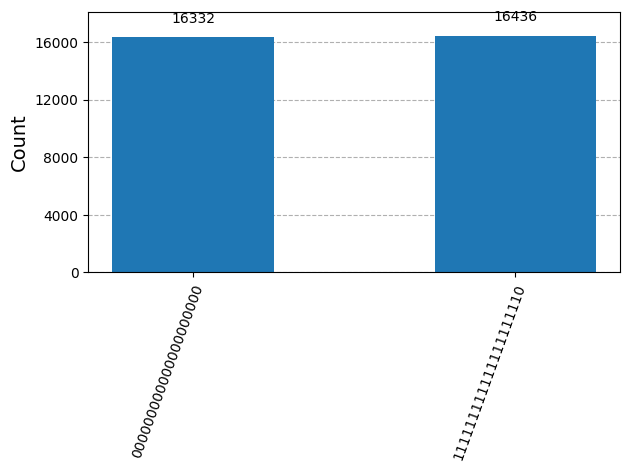

In [13]:
# Higher-shot confirmation on the 21-qubit ring
result_high = simulator.run(qc, shots=32768).result()
counts_high = result_high.get_counts()

print("Higher-shot counts (32768):", counts_high)

# Top 10 states
top_states = sorted(counts_high.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/32768*100:.3f}%)")

plot_histogram(counts_high)

Higher-shot counts (32768): {'000000000000000000000': 32986, '111111111111111111110': 32550}
Top 10 states:
000000000000000000000: 32986 (50.333%)
111111111111111111110: 32550 (49.667%)


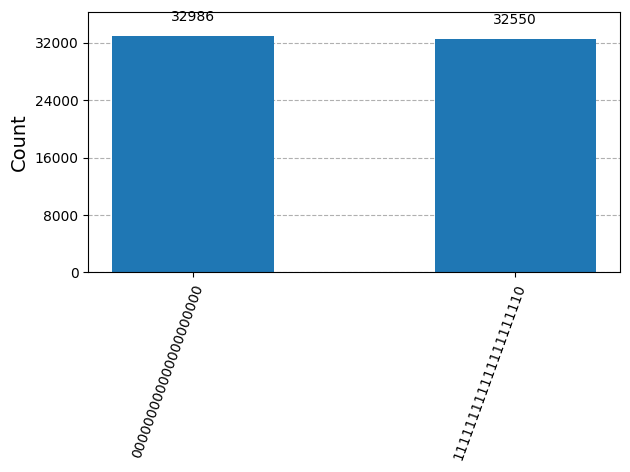

In [14]:
# Higher-shot confirmation on the 21-qubit circular ring
result_high = simulator.run(qc, shots=65536).result()  # or 65536 if RAM allows
counts_high = result_high.get_counts()

print("Higher-shot counts (32768):", counts_high)

# Top 10 states
top_states = sorted(counts_high.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/65536*100:.3f}%)")

plot_histogram(counts_high)

Higher-shot counts (32768): {'000000000000000000000': 65844, '111111111111111111110': 65228}
Top 10 states:
000000000000000000000: 65844 (50.235%)
111111111111111111110: 65228 (49.765%)


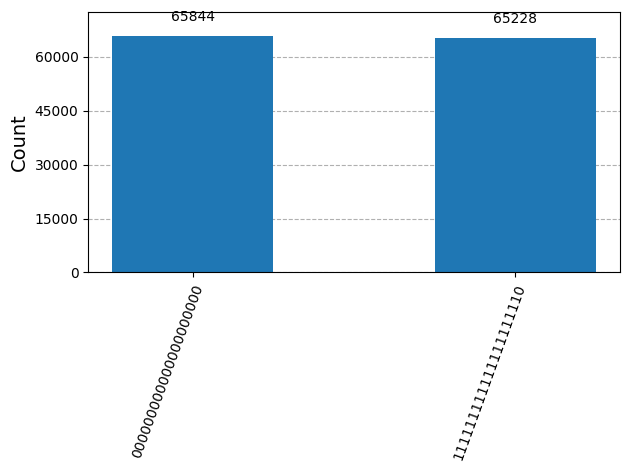

In [15]:
# Higher-shot confirmation on the 21-qubit circular ring
result_high = simulator.run(qc, shots=131072).result()  # or 65536 if RAM allows
counts_high = result_high.get_counts()

print("Higher-shot counts (32768):", counts_high)

# Top 10 states
top_states = sorted(counts_high.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/131072*100:.3f}%)")

plot_histogram(counts_high)

Counts (21-qubit ring + uniform Berard): {'111001111110011101001': 1, '110111111010101110001': 1, '011000111101010010011': 1, '111001110100101110010': 1, '110000110000000100101': 1, '110010011010111111010': 1, '110000100000111111011': 1, '010001110100001100011': 1, '111101011100111100001': 1, '101100111010111100011': 1, '000011111010001100110': 1, '110000110100011010011': 1, '110000100100111111010': 1, '110000100000001010000': 1, '110000011010000000001': 1, '110011111001011101011': 1, '111000011001001010001': 1, '111001111100011011011': 1, '111010111001100001000': 1, '111010111001010101001': 1, '111001011000111100000': 1, '110101111000111110101': 1, '100000110100101100100': 1, '111100111000101101001': 1, '110101011100001100001': 1, '111000101100111110011': 1, '101000011100001101000': 1, '111000111101111110001': 1, '110101110101011110011': 1, '110000111010101101001': 1, '100001111100000100001': 1, '110001010000101000101': 1, '100100111100101100001': 1, '111101011000111110011': 1, '11100

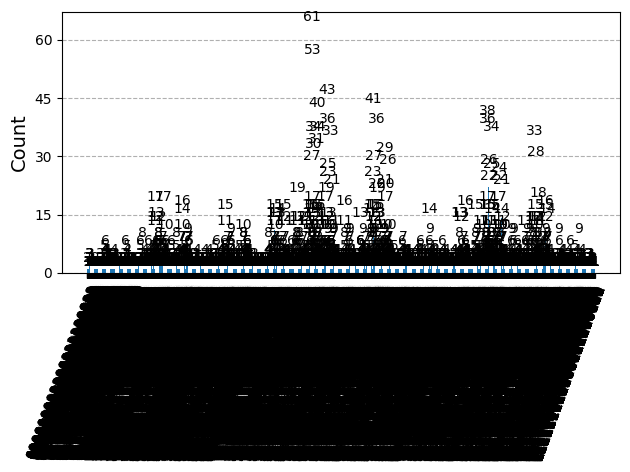

In [16]:
# ────────────────────────────────────────────────
# 21-qubit Ring + Uniform Berard on all qubits
# ────────────────────────────────────────────────

n = 21
qc_berard = QuantumCircuit(n)

# Superposition on all
qc_berard.h(range(n))

# Circular entanglement
for i in range(n - 1):
    qc_berard.cx(i, i+1)
qc_berard.cx(n-1, 0)

# Tau harmonics cycled
for i in range(n):
    k = (i % 7) + 1
    qc_berard.rz(2 * np.pi * k / 7, i)

# Uniform Berard on all qubits
berard_angle = 1.054
for i in range(n):
    qc_berard.ry(berard_angle, i)

qc_berard.measure_all()

# Simulate
result_berard = simulator.run(qc_berard, shots=16384).result()
counts_berard = result_berard.get_counts()

print("Counts (21-qubit ring + uniform Berard):", counts_berard)

# Top 10
top_states = sorted(counts_berard.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count/16384*100:.2f}%)")

plot_histogram(counts_berard)

Running 21-qubit ring + uniform Berard (32,768 shots)...

High-shot counts (21-qubit ring + uniform Berard on all qubits):
{'100000111101001100000': 1, '101001110000010000101': 1, '101000110000011010000': 1, '101000111000111100100': 1, '100001101101110101001': 1, '100010011000011000001': 1, '010000111010101110001': 1, '111001110010011110101': 1, '011001110001001110000': 1, '111001101100111110001': 1, '110010110100001100010': 1, '110100111000111111001': 1, '000000101100110110001': 1, '111000111000110101011': 1, '110010111001101110010': 1, '011011110100011010011': 1, '101101111010111110111': 1, '111010110000011000011': 1, '010000111010001110001': 1, '110000111110011101001': 1, '111000111000110101000': 1, '100001110000001100000': 1, '110000011101111000001': 1, '110000000101011010001': 1, '111011101000011111011': 1, '110001110101111100010': 1, '111000111100011101000': 1, '100001111101101110000': 1, '100000111000111011000': 1, '111000111011101110001': 1, '111111111100111001001': 1, '1001000

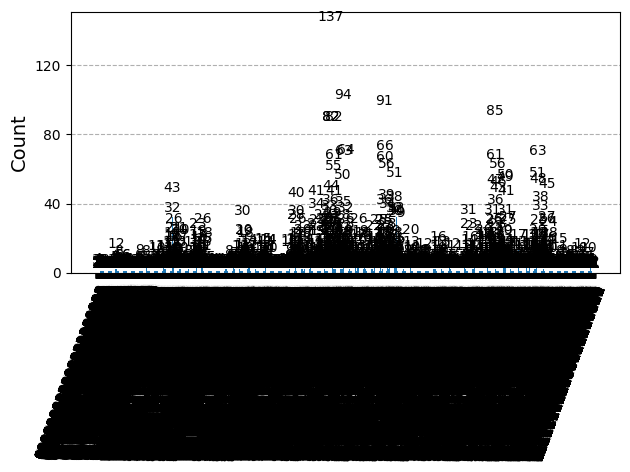

In [17]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Uniform Berard (all qubits) – High-Shot Sim
# ────────────────────────────────────────────────

n = 21
qc_berard = QuantumCircuit(n)

# Superposition on all qubits for balance
qc_berard.h(range(n))

# Circular entanglement: chain + wrap-around
for i in range(n - 1):
    qc_berard.cx(i, i + 1)
qc_berard.cx(n - 1, 0)  # q20 → q0 closes ring

# Tau harmonics cycled 1/7
for i in range(n):
    k = (i % 7) + 1
    qc_berard.rz(2 * np.pi * k / 7, i)

# Uniform Berard on EVERY qubit
berard_angle = 1.054
for i in range(n):
    qc_berard.ry(berard_angle, i)

# Measure all
qc_berard.measure_all()

# Run high-shot simulation
print("Running 21-qubit ring + uniform Berard (32,768 shots)...")
result_berard = simulator.run(qc_berard, shots=32768).result()
counts_berard = result_berard.get_counts()

print("\nHigh-shot counts (21-qubit ring + uniform Berard on all qubits):")
print(counts_berard)

# Top 10 states
top_states = sorted(counts_berard.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count / 32768 * 100:.3f}%)")

# Plot histogram
plot_histogram(counts_berard)

Starting Berard angle scan on 21-qubit ring...
Angle 0.500 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.33
Angle 0.600 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.25
Angle 0.700 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.00
Angle 0.800 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.12
Angle 0.900 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.08
Angle 1.000 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.16
Angle 1.100 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.04
Angle 1.200 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.18
Angle 1.300 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.07
Angle 1.400 rad → 000...:     0 (  0.0%), 111...10:     0 (  0.0%), top/second ratio: 1.45
Angle 1.500 rad → 000...:     0 (  0.0%), 1

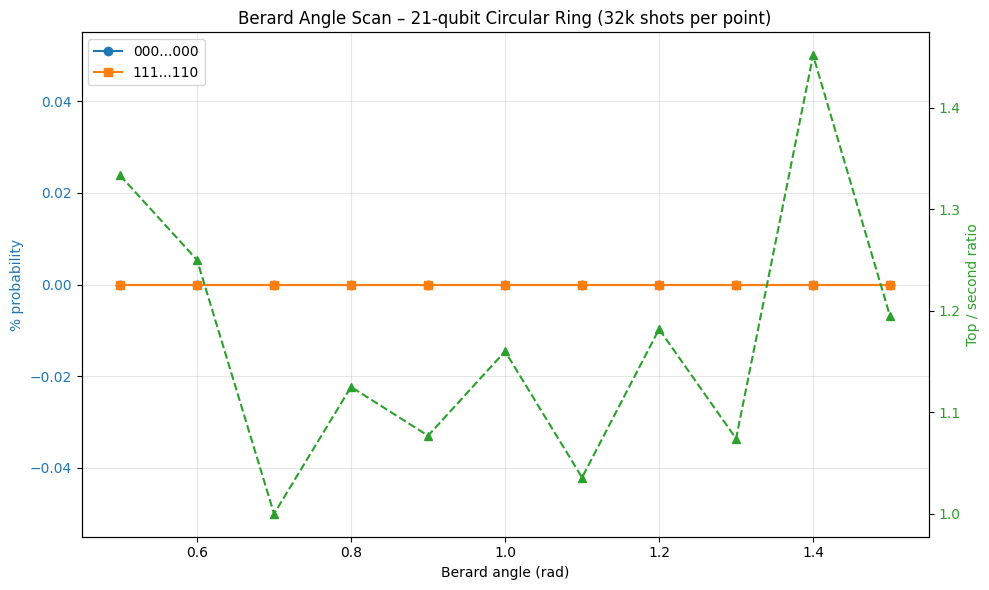

Scan complete.


In [18]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Berard Angle Scan – 21-qubit circular ring
# ────────────────────────────────────────────────

n = 21
shots_per_angle = 8192
angles = np.linspace(0.5, 1.5, 11)  # 11 points around 1.054

p_allzero = []   # % of '000...000'
p_almostone = [] # % of '111...110'
top_state_ratios = []  # ratio of top state / second top

simulator = AerSimulator()

print("Starting Berard angle scan on 21-qubit ring...")
for idx, angle in enumerate(angles):
    qc = QuantumCircuit(n)
    
    # Superposition on all
    qc.h(range(n))
    
    # Circular CX chain + wrap-around
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.cx(n - 1, 0)
    
    # Tau harmonics cycled 1/7
    for i in range(n):
        k = (i % 7) + 1
        qc.rz(2 * np.pi * k / 7, i)
    
    # Uniform Berard on all qubits
    for i in range(n):
        qc.ry(angle, i)
    
    qc.measure_all()
    
    result = simulator.run(qc, shots=shots_per_angle).result()
    counts = result.get_counts()
    
    # Get counts for key states (pad with zeros if missing)
    c_zero = counts.get('0'*n, 0)
    c_almost_one = counts.get('1'*(n-1) + '0', 0)
    
    p_allzero.append(c_zero / shots_per_angle * 100)
    p_almostone.append(c_almost_one / shots_per_angle * 100)
    
    # Top 2 states ratio
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    if len(sorted_counts) >= 2:
        top_ratio = sorted_counts[0][1] / sorted_counts[1][1]
    else:
        top_ratio = float('inf')  # only one state
    top_state_ratios.append(top_ratio)
    
    print(f"Angle {angle:.3f} rad → "
          f"000...: {c_zero:5d} ({c_zero/shots_per_angle*100:5.1f}%), "
          f"111...10: {c_almost_one:5d} ({c_almost_one/shots_per_angle*100:5.1f}%), "
          f"top/second ratio: {top_ratio:.2f}")

# ────────────────────────────────────────────────
# Plot results
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Berard angle (rad)')
ax1.set_ylabel('% probability', color='tab:blue')
ax1.plot(angles, p_allzero, color='tab:blue', marker='o', label='000...000')
ax1.plot(angles, p_almostone, color='tab:orange', marker='s', label='111...110')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Top / second ratio', color='tab:green')
ax2.plot(angles, top_state_ratios, color='tab:green', marker='^', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Berard Angle Scan – 21-qubit Circular Ring (32k shots per point)')
plt.tight_layout()
plt.show()

print("Scan complete.")

Starting refined Berard angle scan (0.9–1.2 rad, 32k shots each)...
Angle 0.9000 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.429, non-zero states: 20783
Angle 0.9150 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.293, non-zero states: 20266
Angle 0.9300 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.228, non-zero states: 19687
Angle 0.9450 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.355, non-zero states: 19238
Angle 0.9600 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.114, non-zero states: 18717
Angle 0.9750 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.085, non-zero states: 18362
Angle 0.9900 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.273, non-zero states: 17963
Angle 1.0050 rad → 000...:      0 ( 0.00%), 111...10:      0 ( 0.00%), top/second ratio: 1.211, non

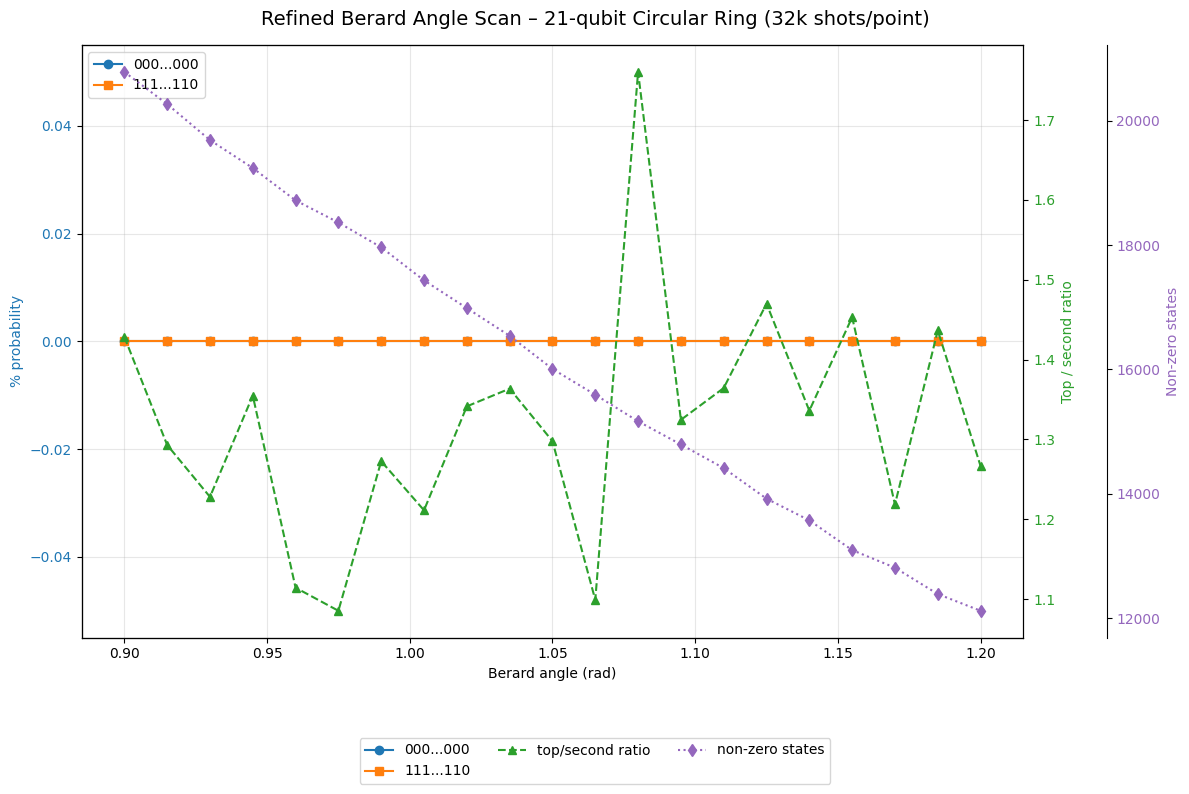

Refined scan complete.


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Refined Berard Angle Scan – 21-qubit circular ring
# Zoom: 0.9–1.2 rad (around 1.054), 21 points
# ────────────────────────────────────────────────

n = 21
shots_per_angle = 32768
angles = np.linspace(0.9, 1.2, 21)  # 21 points, ~0.014 rad step

p_allzero = []
p_almostone = []
top_ratios = []
num_nonzero_states = []  # how many states have ≥1 count

simulator = AerSimulator()

print("Starting refined Berard angle scan (0.9–1.2 rad, 32k shots each)...")
for idx, angle in enumerate(angles):
    qc = QuantumCircuit(n)
    
    # Superposition on all
    qc.h(range(n))
    
    # Circular entanglement
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.cx(n - 1, 0)
    
    # Tau harmonics cycled 1/7
    for i in range(n):
        k = (i % 7) + 1
        qc.rz(2 * np.pi * k / 7, i)
    
    # Uniform Berard on all qubits
    for i in range(n):
        qc.ry(angle, i)
    
    qc.measure_all()
    
    result = simulator.run(qc, shots=shots_per_angle).result()
    counts = result.get_counts()
    
    # Key states
    c_zero = counts.get('0' * n, 0)
    c_almost_one = counts.get('1' * (n - 1) + '0', 0)
    
    p_allzero.append(c_zero / shots_per_angle * 100)
    p_almostone.append(c_almost_one / shots_per_angle * 100)
    
    # Top/second ratio
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_ratio = sorted_counts[0][1] / sorted_counts[1][1] if len(sorted_counts) >= 2 else float('inf')
    top_ratios.append(top_ratio)
    
    # Number of states with ≥1 count
    num_nonzero = len([c for c in counts.values() if c >= 1])
    num_nonzero_states.append(num_nonzero)
    
    print(f"Angle {angle:.4f} rad → "
          f"000...: {c_zero:6d} ({c_zero/shots_per_angle*100:5.2f}%), "
          f"111...10: {c_almost_one:6d} ({c_almost_one/shots_per_angle*100:5.2f}%), "
          f"top/second ratio: {top_ratio:.3f}, "
          f"non-zero states: {num_nonzero}")

# ────────────────────────────────────────────────
# Plot results
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Berard angle (rad)')
ax1.set_ylabel('% probability', color='tab:blue')
ax1.plot(angles, p_allzero, color='tab:blue', marker='o', label='000...000')
ax1.plot(angles, p_almostone, color='tab:orange', marker='s', label='111...110')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Top / second ratio', color='tab:green')
ax2.plot(angles, top_ratios, color='tab:green', marker='^', linestyle='--', label='top/second ratio')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Non-zero states', color='tab:purple')
ax3.plot(angles, num_nonzero_states, color='tab:purple', marker='d', linestyle=':', label='non-zero states')
ax3.tick_params(axis='y', labelcolor='tab:purple')

fig.suptitle('Refined Berard Angle Scan – 21-qubit Circular Ring (32k shots/point)', fontsize=14)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.tight_layout()
plt.show()

print("Refined scan complete.")

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()

print("Qiskit imports ready")

Qiskit imports ready


Running 21-qubit ring + periodic Berard (every 7th qubit)...

High-shot counts (21-qubit ring + periodic Berard):
{'011101011110101110100': 1, '101011110101011101011': 1, '010111101001000101011': 1, '000101111011110011010': 1, '100100111011111001000': 1, '000000101011010000101': 1, '000000100110001111111': 1, '101100011111011001100': 1, '110011010010000011111': 1, '010011101001000001101': 1, '111101100110010010001': 1, '010111101101010010010': 1, '111010010100011111011': 1, '110001000011000100111': 1, '101100001100001000111': 1, '101001011000010001001': 1, '001010010111110110110': 1, '111000100111101010001': 1, '001111100011100010101': 1, '000010000100110001101': 1, '101101111000011110111': 1, '010010011111110110111': 1, '000000110110111110111': 1, '011110111110110001111': 1, '010001011100110100011': 1, '010111000110111010001': 1, '101001110111111000010': 1, '101100110100000100000': 1, '100000101101001110001': 1, '101010100011011010001': 1, '011101110000011010111': 1, '1110101100111111

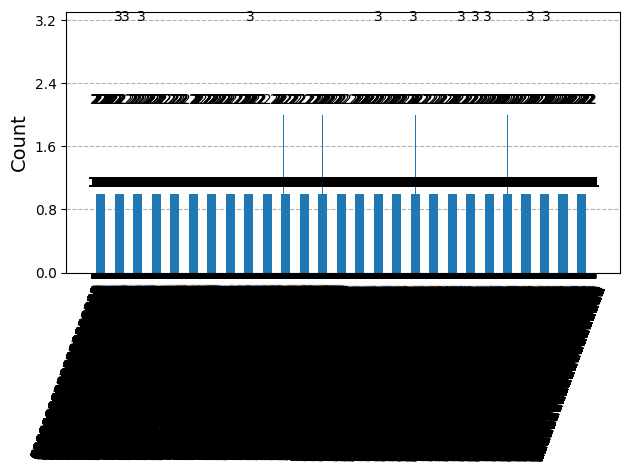

In [3]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Periodic Berard (every 7th qubit)
# Berard ry(1.054) on q0, q7, q14 only
# High-shot simulation (32,768 shots)
# ────────────────────────────────────────────────

n = 21
qc_periodic = QuantumCircuit(n)

# Superposition on all qubits for balance
qc_periodic.h(range(n))

# Circular entanglement chain + wrap-around
for i in range(n - 1):
    qc_periodic.cx(i, i + 1)
qc_periodic.cx(n - 1, 0)  # q20 → q0 closes ring

# Tau harmonics cycled every 7 qubits
for i in range(n):
    k = (i % 7) + 1
    qc_periodic.rz(2 * np.pi * k / 7, i)

# Periodic Berard — only on every 7th qubit (q0, q7, q14)
berard_angle = 1.054
periodic_positions = [0, 7, 14]  # aligned with 1/7 harmonic
for i in periodic_positions:
    qc_periodic.ry(berard_angle, i)

qc_periodic.measure_all()

# Run high-shot simulation
print("Running 21-qubit ring + periodic Berard (every 7th qubit)...")
result_periodic = simulator.run(qc_periodic, shots=32768).result()
counts_periodic = result_periodic.get_counts()

print("\nHigh-shot counts (21-qubit ring + periodic Berard):")
print(counts_periodic)

# Top 10 states
top_states = sorted(counts_periodic.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count / 32768 * 100:.3f}%)")

# Plot histogram
plot_histogram(counts_periodic)

In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()
print("Imports ready")

Imports ready


Running 21-qubit ring + periodic Berard (q0, q7, q14)...

High-shot counts (21-qubit ring + periodic Berard):
{'110100111000010001111': 1, '101101110110011001011': 1, '100000101010011011111': 1, '001010111110010110101': 1, '110010110000111000010': 1, '101100100000110010101': 1, '000111100001110010100': 1, '110000101111001010001': 1, '100010111001010101001': 1, '010111100000101110010': 1, '111100100110010110111': 1, '000100000111100100101': 1, '100001010010000101111': 1, '110000100110011011001': 1, '100100100010100100001': 1, '001010101011000000101': 1, '010010101111100000000': 1, '000111000001000001000': 1, '000110101001110110110': 1, '111100100101010101101': 1, '011011110111011110011': 1, '010001101001000111001': 1, '010100100100110011101': 1, '000001000000010001011': 1, '100100110100110101001': 1, '100000010100001100000': 1, '010101000010101101001': 1, '001101001011100000011': 1, '011110100100000010001': 1, '001011100110111101000': 1, '110001100010111100011': 1, '01001110100101010111

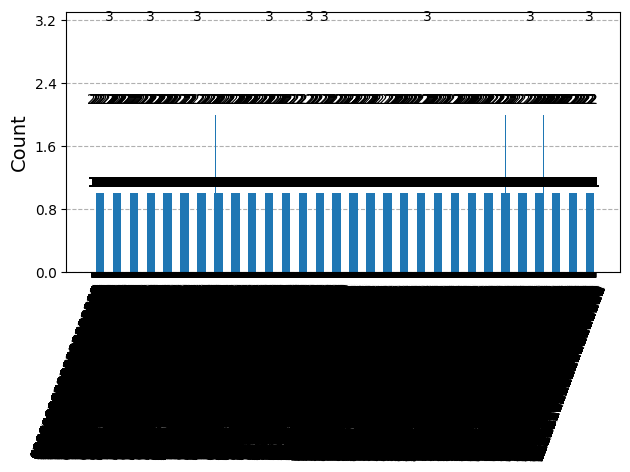

In [5]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Periodic Berard (every 7th qubit only)
# Berard ry(1.054) on q0, q7, q14 — matches Tau harmonic period
# High-shot simulation (32,768 shots)
# ────────────────────────────────────────────────

n = 21
qc_periodic = QuantumCircuit(n)

# Superposition on all qubits for balance
qc_periodic.h(range(n))

# Circular entanglement chain + wrap-around
for i in range(n - 1):
    qc_periodic.cx(i, i + 1)
qc_periodic.cx(n - 1, 0)  # q20 → q0 closes ring

# Tau harmonics cycled every 7 qubits
for i in range(n):
    k = (i % 7) + 1
    qc_periodic.rz(2 * np.pi * k / 7, i)

# Periodic Berard — ONLY on q0, q7, q14
berard_angle = 1.054
periodic_positions = [0, 7, 14]
for i in periodic_positions:
    qc_periodic.ry(berard_angle, i)

qc_periodic.measure_all()

# Run high-shot simulation
print("Running 21-qubit ring + periodic Berard (q0, q7, q14)...")
result_periodic = simulator.run(qc_periodic, shots=32768).result()
counts_periodic = result_periodic.get_counts()

print("\nHigh-shot counts (21-qubit ring + periodic Berard):")
print(counts_periodic)

# Top 10 states
top_states = sorted(counts_periodic.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count / 32768 * 100:.3f}%)")

# Plot histogram
plot_histogram(counts_periodic)

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()
print("Imports ready")

Imports ready


In [ ]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Periodic Berard – Higher Shots (65,536)
# Berard ry(1.054) only on q0, q7, q14
# ────────────────────────────────────────────────

n = 21
shots_high = 65536  # higher for better stats

qc_periodic_high = QuantumCircuit(n)

# Superposition on all
qc_periodic_high.h(range(n))

# Circular CX chain + wrap-around
for i in range(n - 1):
    qc_periodic_high.cx(i, i + 1)
qc_periodic_high.cx(n - 1, 0)

# Tau harmonics cycled 1/7
for i in range(n):
    k = (i % 7) + 1
    qc_periodic_high.rz(2 * np.pi * k / 7, i)

# Periodic Berard – only q0, q7, q14
berard_angle = 1.054
periodic_pos = [0, 7, 14]
for i in periodic_pos:
    qc_periodic_high.ry(berard_angle, i)

qc_periodic_high.measure_all()

# Run higher-shot simulation
print(f"Running periodic Berard with {shots_high} shots...")
result_high = simulator.run(qc_periodic_high, shots=shots_high).result()
counts_high = result_high.get_counts()

print(f"\nHigh-shot counts (periodic Berard, {shots_high} shots):")
print(counts_high)

# Top 20 states
top_states_high = sorted(counts_high.items(), key=lambda x: x[1], reverse=True)[:20]
print(f"\nTop 20 states:")
for state, count in top_states_high:
    print(f"{state}: {count} ({count / shots_high * 100:.4f}%)")

# Non-zero states count
num_nonzero_high = len([c for c in counts_high.values() if c >= 1])
print(f"\nNumber of states with ≥1 count: {num_nonzero_high} / 2^{n} = {num_nonzero_high / 2**n * 100:.6f}%")

# Plot histogram
plot_histogram(counts_high)

Running periodic Berard with 65536 shots...

High-shot counts (periodic Berard, 65536 shots):
{'010101110000110100001': 1, '101010101010110001001': 1, '010001100001110111110': 1, '000010101000100101110': 1, '000010110010111110101': 1, '011011100111100001001': 1, '011100110100010111011': 1, '110001101001111001011': 1, '111100101110011011101': 1, '001111100100110100101': 1, '011011000010000101101': 1, '101000100001100010011': 1, '100110000011111000001': 1, '110001101101100000001': 1, '010101110001011001111': 1, '111111010101100110110': 1, '010110101110011010111': 1, '011100100101011001111': 1, '111010101101111010110': 1, '001011100011010001101': 1, '101001011111011011111': 1, '011010100010101111100': 1, '000000111111111001001': 1, '110101001010000100111': 1, '101111111101010001011': 1, '101101111000010101011': 1, '000001011100101000111': 1, '011011001110011100111': 1, '011010100111010011001': 1, '110111010100010011010': 1, '010010010100011010111': 1, '101111101100000000110': 1, '11011111

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()
print("Imports ready")

Imports ready


In [ ]:
# ────────────────────────────────────────────────
# 21-qubit Periodic Berard – Higher Shots (131,072) + Safe Output
# ────────────────────────────────────────────────

n = 21
shots_ultra = 131072

qc_periodic_ultra = QuantumCircuit(n)
qc_periodic_ultra.h(range(n))

for i in range(n - 1):
    qc_periodic_ultra.cx(i, i + 1)
qc_periodic_ultra.cx(n - 1, 0)

for i in range(n):
    k = (i % 7) + 1
    qc_periodic_ultra.rz(2 * np.pi * k / 7, i)

berard_angle = 1.054
periodic_pos = [0, 7, 14]
for i in periodic_pos:
    qc_periodic_ultra.ry(berard_angle, i)

qc_periodic_ultra.measure_all()

print(f"Running periodic Berard with {shots_ultra} shots...")
result_ultra = simulator.run(qc_periodic_ultra, shots=shots_ultra).result()
counts_ultra = result_ultra.get_counts()

# Save full counts to file (avoids IOPub limit)
import json
with open('periodic_berard_131k_full.json', 'w') as f:
    json.dump(dict(counts_ultra), f, indent=2)
print("Full counts saved to 'periodic_berard_131k_full.json'")

# Print top 30 only
top_states_ultra = sorted(counts_ultra.items(), key=lambda x: x[1], reverse=True)[:30]
print("\nTop 30 states:")
for state, count in top_states_ultra:
    print(f"{state}: {count} ({count / shots_ultra * 100:.5f}%)")

# Non-zero count
num_nonzero_ultra = len([c for c in counts_ultra.values() if c >= 1])
print(f"\nNumber of states with ≥1 count: {num_nonzero_ultra} / 2^{n} = {num_nonzero_ultra / 2**n * 100:.6f}%")

plot_histogram(counts_ultra)

Running periodic Berard with 131072 shots...
Full counts saved to 'periodic_berard_131k_full.json'

Top 30 states:
101000110101111011001: 5 (0.00381%)
110000111001110000101: 4 (0.00305%)
011101110110011001101: 4 (0.00305%)
011000111101011001101: 4 (0.00305%)
010001101001010011101: 4 (0.00305%)
111101100110011010101: 4 (0.00305%)
111110111100010100011: 4 (0.00305%)
111110110101110010101: 4 (0.00305%)
011101100111010000101: 4 (0.00305%)
100101110110111100011: 4 (0.00305%)
110011110000010000001: 4 (0.00305%)
111110111010011010101: 4 (0.00305%)
011101100110011010111: 4 (0.00305%)
000001100010011111101: 4 (0.00305%)
011110101001110000111: 4 (0.00305%)
011110110100111011101: 4 (0.00305%)
111100101000110001101: 4 (0.00305%)
111001111001010111101: 4 (0.00305%)
110000111010110110101: 4 (0.00305%)
111100100101010011001: 4 (0.00305%)
101011110110111000001: 4 (0.00305%)
101111101010111011001: 4 (0.00305%)
001000111001111100001: 4 (0.00305%)
001010111000110001001: 4 (0.00305%)
101101110001110100011

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()
print("Imports ready")

Imports ready


In [ ]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Negative Phase Tau + Periodic Berard
# Negative rz phases + ry(1.054) only on q0, q7, q14
# High-shot simulation (65,536 shots)
# ────────────────────────────────────────────────

n = 21
shots_neg = 65536

qc_neg_periodic = QuantumCircuit(n)

# Superposition on all
qc_neg_periodic.h(range(n))

# Circular CX chain + wrap-around
for i in range(n - 1):
    qc_neg_periodic.cx(i, i + 1)
qc_neg_periodic.cx(n - 1, 0)

# Negative Tau harmonics cycled 1/7
for i in range(n):
    k = (i % 7) + 1
    qc_neg_periodic.rz(-2 * np.pi * k / 7, i)  # ← negative phase flip

# Periodic Berard – only q0, q7, q14
berard_angle = 1.054
periodic_pos = [0, 7, 14]
for i in periodic_pos:
    qc_neg_periodic.ry(berard_angle, i)

qc_neg_periodic.measure_all()

# Run simulation
print(f"Running negative phase + periodic Berard with {shots_neg} shots...")
result_neg = simulator.run(qc_neg_periodic, shots=shots_neg).result()
counts_neg = result_neg.get_counts()

print(f"\nCounts (negative phase + periodic Berard, {shots_neg} shots):")
print(counts_neg)

# Top 30 states
top_states_neg = sorted(counts_neg.items(), key=lambda x: x[1], reverse=True)[:30]
print(f"\nTop 30 states:")
for state, count in top_states_neg:
    print(f"{state}: {count} ({count / shots_neg * 100:.5f}%)")

# Non-zero states count
num_nonzero_neg = len([c for c in counts_neg.values() if c >= 1])
print(f"\nNumber of states with ≥1 count: {num_nonzero_neg} / 2^{n} = {num_nonzero_neg / 2**n * 100:.6f}%")

# Plot histogram
plot_histogram(counts_neg)

Running negative phase + periodic Berard with 65536 shots...

Counts (negative phase + periodic Berard, 65536 shots):
{'011100000110000110110': 1, '111111101110011010101': 1, '010001100010000011101': 1, '101100110111111111001': 1, '100100011000011101011': 1, '111011000110010111110': 1, '001011010011110111101': 1, '100010110011010011101': 1, '011001100000101000100': 1, '001111011101010000011': 1, '010111011010111000011': 1, '111000111101110101001': 1, '011111101100011111101': 1, '011101110101010100101': 1, '100010110010010011001': 1, '111011110000110001111': 1, '000010110010010100011': 1, '111111010101111001001': 1, '111000000001011100101': 1, '111010010010110111111': 1, '110011011000010000101': 1, '101010110111111101111': 1, '110110111000110001100': 1, '111100010001110010011': 1, '110101111000011110101': 1, '001011100000110101001': 1, '111100011001111011100': 1, '101010011110011001001': 1, '111100011110110111000': 1, '001100101010011111101': 1, '100011001011011010001': 1, '111100010001

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

simulator = AerSimulator()
print("Imports ready")

Imports ready


In [ ]:
# ────────────────────────────────────────────────
# 21-qubit Circular Ring + Negative Phase Tau + Periodic Berard
# rz negative on all qubits + ry(1.054) only on q0, q7, q14
# Higher-shot simulation (65,536 shots)
# ────────────────────────────────────────────────

n = 21
shots_neg = 65536

qc_neg_periodic = QuantumCircuit(n)

# Superposition on all qubits
qc_neg_periodic.h(range(n))

# Circular entanglement chain + wrap-around
for i in range(n - 1):
    qc_neg_periodic.cx(i, i + 1)
qc_neg_periodic.cx(n - 1, 0)

# Negative Tau harmonics cycled 1/7
for i in range(n):
    k = (i % 7) + 1
    qc_neg_periodic.rz(-2 * np.pi * k / 7, i)  # ← negative polarity

# Periodic Berard – only q0, q7, q14
berard_angle = 1.054
periodic_pos = [0, 7, 14]
for i in periodic_pos:
    qc_neg_periodic.ry(berard_angle, i)

qc_neg_periodic.measure_all()

# Run simulation
print(f"Running negative phase + periodic Berard with {shots_neg} shots...")
result_neg = simulator.run(qc_neg_periodic, shots=shots_neg).result()
counts_neg = result_neg.get_counts()

print(f"\nCounts (negative phase + periodic Berard, {shots_neg} shots):")
print(counts_neg)

# Top 30 states
top_states_neg = sorted(counts_neg.items(), key=lambda x: x[1], reverse=True)[:30]
print(f"\nTop 30 states:")
for state, count in top_states_neg:
    print(f"{state}: {count} ({count / shots_neg * 100:.5f}%)")

# Non-zero states count
num_nonzero_neg = len([c for c in counts_neg.values() if c >= 1])
print(f"\nNumber of states with ≥1 count: {num_nonzero_neg} / 2^{n} = {num_nonzero_neg / 2**n * 100:.6f}%")

# Plot histogram
plot_histogram(counts_neg)

Running negative phase + periodic Berard with 65536 shots...

Counts (negative phase + periodic Berard, 65536 shots):
{'110100010111010000001': 1, '000111010100010111101': 1, '100111000010000101100': 1, '100101110010111001111': 1, '000011110011100011100': 1, '111101101100001110001': 1, '100101101101110001110': 1, '111101111010110111111': 1, '100010101001110101001': 1, '010110001100011101011': 1, '011010111000111101101': 1, '111001111010110111000': 1, '000000101001010011010': 1, '011000001100011011111': 1, '111000110100101001100': 1, '000010100110010100001': 1, '110100100000010011110': 1, '101101100110111000110': 1, '001110010001111011011': 1, '001100100101110111001': 1, '111000100001111110001': 1, '100010111010111010100': 1, '110101001000010110001': 1, '110001110100010101001': 1, '001101101110011100001': 1, '011011100000111101111': 1, '000001100100111101100': 1, '010111111110111101001': 1, '110011111011010010010': 1, '111001111100110100110': 1, '011100100100001001011': 1, '010101101110

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()
print("Imports ready")

Imports ready


Starting periodic Berard angle scan (q0,q7,q14 only)...
Angle 0.9000 rad → top/second ratio: 1.000, non-zero states: 16273
Angle 0.9214 rad → top/second ratio: 1.000, non-zero states: 16252
Angle 0.9429 rad → top/second ratio: 1.500, non-zero states: 16249
Angle 0.9643 rad → top/second ratio: 1.000, non-zero states: 16261
Angle 0.9857 rad → top/second ratio: 1.000, non-zero states: 16235
Angle 1.0071 rad → top/second ratio: 1.000, non-zero states: 16255
Angle 1.0286 rad → top/second ratio: 1.500, non-zero states: 16239
Angle 1.0500 rad → top/second ratio: 1.000, non-zero states: 16232
Angle 1.0714 rad → top/second ratio: 1.000, non-zero states: 16256
Angle 1.0929 rad → top/second ratio: 1.000, non-zero states: 16241
Angle 1.1143 rad → top/second ratio: 1.000, non-zero states: 16230
Angle 1.1357 rad → top/second ratio: 1.000, non-zero states: 16222
Angle 1.1571 rad → top/second ratio: 1.500, non-zero states: 16233
Angle 1.1786 rad → top/second ratio: 1.000, non-zero states: 16217
Angle 

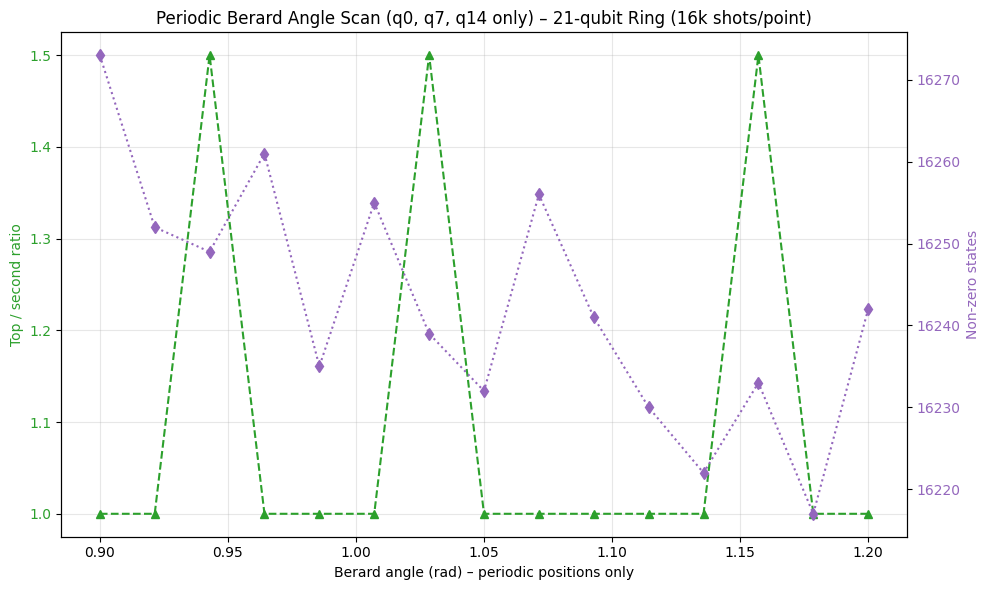

Periodic angle scan complete.


In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Periodic Berard Angle Scan – only q0, q7, q14
# Zoom: 0.9–1.2 rad, 15 points, 16k shots each
# ────────────────────────────────────────────────

n = 21
shots_per = 16384
angles = np.linspace(0.9, 1.2, 15)  # 15 points

top_ratios = []
num_nonzero_list = []

simulator = AerSimulator()

print("Starting periodic Berard angle scan (q0,q7,q14 only)...")
for idx, angle in enumerate(angles):
    qc = QuantumCircuit(n)
    
    qc.h(range(n))  # superposition
    
    # Circular CX + wrap-around
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.cx(n - 1, 0)
    
    # Tau harmonics (positive)
    for i in range(n):
        k = (i % 7) + 1
        qc.rz(2 * np.pi * k / 7, i)
    
    # Periodic Berard – only q0, q7, q14
    periodic_pos = [0, 7, 14]
    for i in periodic_pos:
        qc.ry(angle, i)
    
    qc.measure_all()
    
    result = simulator.run(qc, shots=shots_per).result()
    counts = result.get_counts()
    
    # Top/second ratio
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_ratio = sorted_counts[0][1] / sorted_counts[1][1] if len(sorted_counts) >= 2 else float('inf')
    top_ratios.append(top_ratio)
    
    # Non-zero states
    num_nonzero = len([c for c in counts.values() if c >= 1])
    num_nonzero_list.append(num_nonzero)
    
    print(f"Angle {angle:.4f} rad → top/second ratio: {top_ratio:.3f}, non-zero states: {num_nonzero}")

# ────────────────────────────────────────────────
# Plot results
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Berard angle (rad) – periodic positions only')
ax1.set_ylabel('Top / second ratio', color='tab:green')
ax1.plot(angles, top_ratios, color='tab:green', marker='^', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Non-zero states', color='tab:purple')
ax2.plot(angles, num_nonzero_list, color='tab:purple', marker='d', linestyle=':')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.title('Periodic Berard Angle Scan (q0, q7, q14 only) – 21-qubit Ring (16k shots/point)')
plt.tight_layout()
plt.show()

print("Periodic angle scan complete.")

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()
print("Imports ready")

Imports ready


Starting negative phase + periodic Berard angle scan...
Angle 0.9000 rad → top/second ratio: 1.000, non-zero states: 16267
Angle 0.9214 rad → top/second ratio: 1.000, non-zero states: 16248
Angle 0.9429 rad → top/second ratio: 1.000, non-zero states: 16257
Angle 0.9643 rad → top/second ratio: 1.500, non-zero states: 16248
Angle 0.9857 rad → top/second ratio: 1.000, non-zero states: 16246
Angle 1.0071 rad → top/second ratio: 1.500, non-zero states: 16234
Angle 1.0286 rad → top/second ratio: 1.500, non-zero states: 16241
Angle 1.0500 rad → top/second ratio: 1.500, non-zero states: 16251
Angle 1.0714 rad → top/second ratio: 1.000, non-zero states: 16236
Angle 1.0929 rad → top/second ratio: 1.000, non-zero states: 16237
Angle 1.1143 rad → top/second ratio: 1.000, non-zero states: 16238
Angle 1.1357 rad → top/second ratio: 1.000, non-zero states: 16233
Angle 1.1571 rad → top/second ratio: 1.500, non-zero states: 16245
Angle 1.1786 rad → top/second ratio: 1.000, non-zero states: 16259
Angle 

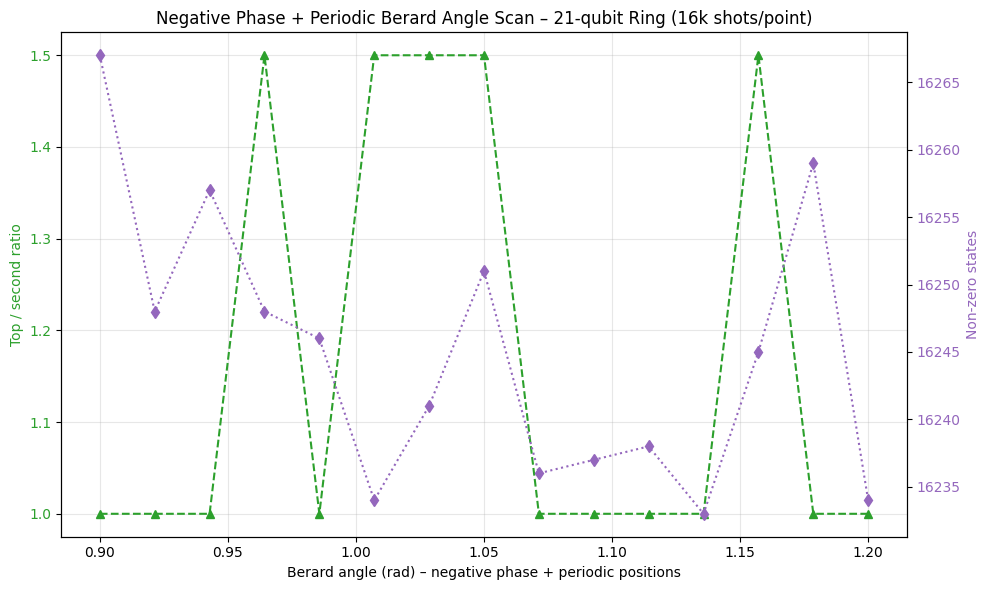

Negative phase periodic angle scan complete.


In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Negative Phase + Periodic Berard Angle Scan
# rz negative on all + ry(angle) only on q0, q7, q14
# Zoom: 0.90–1.20 rad, 15 points, 16k shots each
# ────────────────────────────────────────────────

n = 21
shots_per = 16384
angles = np.linspace(0.90, 1.20, 15)

top_ratios_neg = []
num_nonzero_neg = []

simulator = AerSimulator()

print("Starting negative phase + periodic Berard angle scan...")
for idx, angle in enumerate(angles):
    qc = QuantumCircuit(n)
    
    qc.h(range(n))  # superposition
    
    # Circular CX + wrap-around
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.cx(n - 1, 0)
    
    # Negative Tau harmonics
    for i in range(n):
        k = (i % 7) + 1
        qc.rz(-2 * np.pi * k / 7, i)  # ← negative polarity
    
    # Periodic Berard – only q0, q7, q14
    periodic_pos = [0, 7, 14]
    for i in periodic_pos:
        qc.ry(angle, i)
    
    qc.measure_all()
    
    result = simulator.run(qc, shots=shots_per).result()
    counts = result.get_counts()
    
    # Top/second ratio
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_ratio = sorted_counts[0][1] / sorted_counts[1][1] if len(sorted_counts) >= 2 else float('inf')
    top_ratios_neg.append(top_ratio)
    
    # Non-zero states
    num_nonzero = len([c for c in counts.values() if c >= 1])
    num_nonzero_neg.append(num_nonzero)
    
    print(f"Angle {angle:.4f} rad → top/second ratio: {top_ratio:.3f}, non-zero states: {num_nonzero}")

# ────────────────────────────────────────────────
# Plot results (compare to positive phase if you have data)
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Berard angle (rad) – negative phase + periodic positions')
ax1.set_ylabel('Top / second ratio', color='tab:green')
ax1.plot(angles, top_ratios_neg, color='tab:green', marker='^', linestyle='--', label='negative phase')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Non-zero states', color='tab:purple')
ax2.plot(angles, num_nonzero_neg, color='tab:purple', marker='d', linestyle=':', label='negative phase')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.title('Negative Phase + Periodic Berard Angle Scan – 21-qubit Ring (16k shots/point)')
plt.tight_layout()
plt.show()

print("Negative phase periodic angle scan complete.")